In [2]:
import os
from glob import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

plt.rcParams['font.family'] = "Times New Roman"

In [4]:
metrics_json_paths = glob(f'.{os.sep}logs{os.sep}finetune_20250720{os.sep}*{os.sep}*{os.sep}*{os.sep}*{os.sep}*{os.sep}*{os.sep}*{os.sep}assessment_metrics.json')
print(f'Found {len(metrics_json_paths)} metrics JSON files.')

Found 0 metrics JSON files.


In [135]:
metrics_records = []
for metrics_json in metrics_json_paths:
    split_path_parts = metrics_json.split(os.sep)
    for i, part in enumerate(split_path_parts):
        print(f'Part {i}: {part}')
    model = split_path_parts[3]
    pretrain_method = split_path_parts[4]
    frozen_encoder = split_path_parts[6] == 'frozenencoder_true'
    n_train = split_path_parts[7]
    fold = split_path_parts[8].split('_')[-1]
    
    metrics = json.load(open(metrics_json, 'r'))
    metrics['model'] = model
    metrics['pretrain_method'] = pretrain_method
    metrics['frozen_encoder'] = frozen_encoder
    metrics['n_train'] = n_train
    metrics['fold'] = fold
    metrics_records.append(metrics)

metrics_df = pd.DataFrame(metrics_records)
metrics_df = metrics_df.loc[(metrics_df['frozen_encoder'] == False) | ((metrics_df['frozen_encoder'] == True) & (metrics_df['model'] == 'linear_probe'))]
# metrics_df.loc[metrics_df['model'] == 'linear_probe']
display(metrics_df.sort_values(by='macro_f1_score', ascending=False))

Part 0: .
Part 1: logs
Part 2: finetune_20250720
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 250
Part 8: fold_1
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250720
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 250
Part 8: fold_2
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250720
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 250
Part 8: fold_3
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250720
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 250
Part 8: fold_4
Part 9: test
Part 10: assessment_metrics.json
Part 0: .
Part 1: logs
Part 2: finetune_20250720
Part 3: attention_unet
Part 4: byol
Part 5: randinit_false
Part 6: frozenencoder_false
Part 7: 500
Part 8: fold_1
P

,accuracy,f1_score,precision,recall,jaccard,kappa,cross_entropy,brier_score,macro_f1_score,macro_precision,...,weighted_precision,weighted_recall,weighted_jaccard,weighted_cross_entropy,weighted_brier_score,model,pretrain_method,frozen_encoder,n_train,fold
397,0.87420,0.87420,0.87420,0.87420,0.776514,0.780977,1.555658,0.027611,0.758441,0.780296,...,0.873818,0.87420,0.784597,1.555658,0.027611,unet,byol,False,500,2
10,0.87000,0.87000,0.87000,0.87000,0.769912,0.772725,1.547689,0.027623,0.755805,0.792217,...,0.869808,0.87000,0.777545,1.547689,0.027623,attention_unet,byol,False,750,1
403,0.86608,0.86608,0.86608,0.86608,0.763793,0.767772,1.531117,0.027326,0.749963,0.778301,...,0.868009,0.86608,0.774044,1.531117,0.027326,unet,byol,False,750,2
399,0.86668,0.86668,0.86668,0.86668,0.764727,0.768611,1.586395,0.030452,0.746120,0.780185,...,0.866062,0.86668,0.774897,1.586395,0.030452,unet,byol,False,500,4
7,0.86540,0.86540,0.86540,0.86540,0.762736,0.766274,1.557559,0.028729,0.744720,0.772592,...,0.864943,0.86540,0.773159,1.557559,0.028729,attention_unet,byol,False,500,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,0.02288,0.02288,0.02288,0.02288,0.011572,0.000000,NaN,NaN,0.005592,0.002860,...,0.000523,0.02288,0.000523,0.000000,0.000000,danet,none,False,500,5
164,0.02288,0.02288,0.02288,0.02288,0.011572,0.000000,NaN,NaN,0.005592,0.002860,...,0.000523,0.02288,0.000523,0.000000,0.000000,danet,none,False,750,1
165,0.02288,0.02288,0.02288,0.02288,0.011572,0.000000,NaN,NaN,0.005592,0.002860,...,0.000523,0.02288,0.000523,0.000000,0.000000,danet,none,False,750,2
166,0.02288,0.02288,0.02288,0.02288,0.011572,0.000000,NaN,NaN,0.005592,0.002860,...,0.000523,0.02288,0.000523,0.000000,0.000000,danet,none,False,750,3


In [5]:
metrics_df = pd.read_csv('./logs/finetune_20250720/summary.csv')

In [14]:
lp_df = metrics_df.loc[metrics_df['model'] == 'linear_probe']
lp_df = lp_df[['pretrain_method', 'n_train', 'macro_jaccard']]

for n_train in lp_df['n_train'].unique():
    n_train_df = lp_df.loc[lp_df['n_train'] == n_train]
    random_miou = n_train_df.loc[n_train_df['pretrain_method'] == 'none', 'macro_jaccard'].values[0]
    byol_miou = n_train_df.loc[n_train_df['pretrain_method'] == 'byol', 'macro_jaccard'].values[0]
    improvement = byol_miou - random_miou
    # print(f'N_train: {n_train}, Random mIoU: {random_miou:.4f}, BYOL mIoU: {byol_miou:.4f}, Improvement: {improvement:.4f}')
    
    byol_randinint_miou = n_train_df.loc[n_train_df['pretrain_method'] == 'byol_randinit', 'macro_jaccard'].values[0]
    improvement_randinit = byol_randinint_miou - random_miou
    # print(f'N_train: {n_train}, BYOL randinit mIoU: {byol_randinint_miou:.4f}, Improvement over randinit: {improvement_randinit:.4f}')
    
    # imrpovements over ImageNet
    imagenet_miou = n_train_df.loc[n_train_df['pretrain_method'] == 'imagenet', 'macro_jaccard'].values[0]
    improvement_imagenet = byol_miou - imagenet_miou
    print(f'N_train: {n_train}, ImageNet mIoU: {imagenet_miou:.4f}, BYOL mIoU: {byol_miou:.4f}, BYOL Randinit mIoU: {byol_randinint_miou:.4f}, Improvement over ImageNet: {improvement_imagenet:.4f}')
# lp_df

N_train: 250, ImageNet mIoU: 0.2428, BYOL mIoU: 0.3624, BYOL Randinit mIoU: 0.4109, Improvement over ImageNet: 0.1195
N_train: 500, ImageNet mIoU: 0.2708, BYOL mIoU: 0.4113, BYOL Randinit mIoU: 0.4133, Improvement over ImageNet: 0.1406
N_train: 750, ImageNet mIoU: 0.2770, BYOL mIoU: 0.4196, BYOL Randinit mIoU: 0.4271, Improvement over ImageNet: 0.1426


In [136]:
metrics_df.groupby(['model', 'pretrain_method', 'frozen_encoder', 'n_train']).count()

accuracy  f1_score  \
model          pretrain_method frozen_encoder n_train                       
attention_unet byol            False          250             4         4   
                                              500             6         6   
                                              750             4         4   
               byol_randinit   False          250             4         4   
                                              500             6         6   
...                                                         ...       ...   
upernet        imagenet        False          500             6         6   
                                              750             4         4   
               none            False          250             4         4   
                                              500             6         6   
                                              750             4         4   

                                                       precision  recall  \
model          pretrain_method frozen_encoder n_train                      
attention_unet byol            False          250              4       4   
                                              500              6       6   
                                              750              4       4   
               byol_randinit   False          250              4       4   
                                              500              6       6   
...                                                          ...     ...   
upernet        imagenet        False          500              6       6   
                                              750              4       4   
               none            False          250              4       4   
                                              500              6       6   
                                              750              4       4   

                                                       jaccard  kappa  \
model          pretrain_method frozen_encoder n_train                   
attention_unet byol            False          250            4      4   
                                              500            6      6   
                                              750            4      4   
               byol_randinit   False          250            4      4   
                                              500            6      6   
...                                                        ...    ...   
upernet        imagenet        False          500            6      6   
                                              750            4      4   
               none            False          250            4      4   
                                              500            6      6   
                                              750            4      4   

                                                       cross_entropy  \
model          pretrain_method frozen_encoder n_train                  
attention_unet byol            False          250                  4   
                                              500                  6   
                                              750                  4   
               byol_randinit   False          250                  4   
                                              500                  6   
...                                                              ...   
upernet        imagenet        False          500                  6   
                                              750                  4   
               none            False          250                  4   
                                              500                  6   
                                              750                  4   

                                                       brier_score  \
model          pretrain_method frozen_encoder n_train                
attention_unet byol            False 

In [ ]:


# fig, ax = plt.subplots(2, 3, figsize=(18, 10), sharey=True)

# for i, frozen_encoder in enumerate(metrics_df['frozen_encoder'].unique()):
#     # print(i, model)
#     for j, model in enumerate(metrics_df['model'].unique()):
#         # metrics_df['model']
#         # print(j, frozen_encoder)
#         subset = metrics_df[(metrics_df['model'] == model) & (metrics_df['frozen_encoder'] == frozen_encoder)]
#         # sns.lineplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', ax=ax[i, j])
#         # sns.catplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', kind='point', ax=ax[i, j], markers=['o', 's', 'D'], linestyles=['-', '--', ':'])
#         # sns.pointplot(data=subset, x='n_train', y='macro_f1_score', hue='pretrain_method', ax=ax[i, j], dodge=True, errorbar='iqr')
#         sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', ax=ax[i, j], palette='Set2', boxprops={'alpha': 0.4}, showfliers=False)
#         sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', ax=ax[i, j], jitter=True, dodge=True, palette='Set2', size=10)
#         handles, labels = ax[i, j].get_legend_handles_labels()
#         # ax[i, j].legend(handles=[(handles[0], handles[2]), (handles[1], handles[3])],
#                 # labels=['BYOL', 'ImageNet'],
#                 # loc='lower right', handlelength=4,
#                 # handler_map={tuple: HandlerTuple(ndivide=None)})
#         ax[i, j].set_title(f'Model: {model}, Frozen Encoder: {frozen_encoder}')
#         ax[i, j].set_xlabel('Number of Training Samples')
#         ax[i, j].set_ylabel('mIOU')

C:\Users\dh2306\AppData\Local\Temp\ipykernel_71908\448445254.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


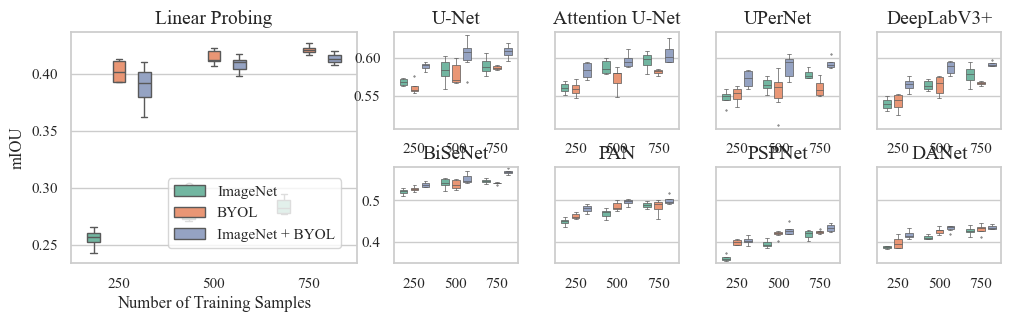

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'times new roman'

size = 3
fig = plt.figure(figsize=(4*size, size))
gs = fig.add_gridspec(2, 6, hspace=0.4, wspace=0.3)

# Create the linear probe subplot (spans 2 rows)
lp_ax = fig.add_subplot(gs[0:2, 0:2])

# Create top row axes with shared y-axis
top_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in top row
        ax = fig.add_subplot(gs[0, j])
    else:  # Share y-axis with first subplot
        # ax = fig.add_subplot(gs[0, j], sharey=top_axes[0])
        ax = fig.add_subplot(gs[0, j])
    top_axes.append(ax)

# Create bottom row axes with shared y-axis
bottom_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in bottom row
        # ax = fig.add_subplot(gs[1, j])
        ax = fig.add_subplot(gs[1, j]) #, sharey=top_axes[0])
    else:  # Share y-axis with first subplot
        # ax = fig.add_subplot(gs[1, j], sharey=bottom_axes[0])
        ax = fig.add_subplot(gs[1, j])
    bottom_axes.append(ax)

# Combine all axes for easy iteration
axes = top_axes + bottom_axes

# metrics_df_temp = metrics_df.copy()
# let's create some synthetic data real quick:
# new_rows = []
# metrics_df_temp.loc[~metrics_df_temp['model'].isin(['linear_probe', 'unet', 'deeplabv3plus']), 'macro_jaccard'] += 0.2

# for each observation where only 1 fold is present, create 5 more observations with the same data but different folds
# new_rows = []
# for i, row in metrics_df_temp.iterrows():
#     if row['model'] not in ['linear_probe', 'unet', 'deeplabv3plus']:
#         row['macro_jaccard'] += 0.2  # adjust the macro jaccard score for now

# for i, row in metrics_df_temp.iterrows():
    # if row['fold'] == '1' and row['model'] not in ['unet', 'deeplabv3plus']:
        # for fold in range(1, 6):
            # new_row = row.copy()
            # new_row['fold'] = fold
            # new_row['macro_jaccard'] += np.random.uniform(-0.01, 0.01)  # add some noise
            # new_row['macro_jaccard'] += 0.25
            # new_rows.append(new_row)
            # metrics_df_temp = metrics_df_temp.append(new_row, ignore_index=True)
# synthetic_df = pd.DataFrame(new_rows)
# metrics_df_temp = pd.concat([metrics_df_temp, synthetic_df], ignore_index=True)

metrics_df_temp = metrics_df.copy()
metrics_df_temp = metrics_df_temp.loc[metrics_df_temp['pretrain_method'] != 'none']

# rename to proper model names (i.e., unet -> U-Net)
metrics_df_temp['model'] = metrics_df_temp['model'].replace({
    'unet': 'U-Net',
    'deeplabv3plus': 'DeepLabV3+',
    'pan': 'PAN',
    'danet': 'DANet',
    'upernet': 'UPerNet',
    'bisenet': 'BiSeNet',
    'pspnet': 'PSPNet',
    'attention_unet': 'Attention U-Net',
})

metrics_df_temp['Pretrain Method'] = metrics_df_temp['pretrain_method'].replace({
    'byol': 'ImageNet + BYOL',
    'imagenet': 'ImageNet',
    'byol_randinit': 'BYOL'
})
metrics_df_temp['Pretrain Method'] = metrics_df_temp['Pretrain Method'].astype('category').cat.reorder_categories([
    'ImageNet', 'BYOL', 'ImageNet + BYOL'
], ordered=True)

# Plot linear probe
# sns.boxplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'], 
#             x='n_train', y='macro_jaccard', hue='pretrain_method', 
#             ax=lp_ax, palette='Set2', boxprops={'alpha': 0.4}, showfliers=False)
sns.boxplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'],
                x='n_train', y='macro_jaccard', hue='Pretrain Method', 
                ax=lp_ax, dodge=True, palette='Set2', gap=0.5)
lp_ax.set_title('Linear Probing')
lp_ax.set_xlabel('Number of Training Samples')
lp_ax.set_ylabel('mIOU')

# move legend to lower right corner
handles, labels = lp_ax.get_legend_handles_labels()
lp_ax.legend(handles=handles, labels=labels, loc='lower right', bbox_to_anchor=(1., 0), borderaxespad=1.)


metrics_df_temp = metrics_df_temp.loc[metrics_df_temp['model'] != "linear_probe"]

# order models in a certain order

metrics_df_temp['model'] = metrics_df_temp['model'].astype('category')
metrics_df_temp['model'] = metrics_df_temp['model'].cat.reorder_categories([
    'U-Net', 'Attention U-Net', 'DeepLabV3+', 'UPerNet',
    'BiSeNet', 'DANet', 'PAN', 'PSPNet',
], ordered=True)

# Plot other models

model_list = metrics_df_temp.sort_values(by='macro_jaccard', ascending=False)['model'].unique()

for i, (ax, model) in enumerate(zip(axes, model_list)):
    if model == 'linear_probe':
        continue
    
    subset = metrics_df_temp[(metrics_df_temp['model'] == model) & (metrics_df_temp['frozen_encoder'] == False)]
    
    # if model not in ['deeplabv3plus', 'unet']:
        # subset['macro_jaccard'] = subset['macro_jaccard'] + 0.2
    
    # sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='Pretrain Method', 
    #             ax=ax, palette='Set2', boxprops={'alpha': 0.4}, showfliers=False, legend=False)
    sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='Pretrain Method',
                  ax=ax, dodge=True, palette='Set2', 
                    legend=False, gap=0.3, fliersize=0.5, linewidth=0.5)
    
    ax.set_title(f'{model}')
    ax.set_xlabel('')
    
    # Only show y-label on leftmost plots of each row
    # if ax in [top_axes[0], bottom_axes[0]]:
    #     ax.set_ylabel('mIOU')
    # else:
    ax.set_ylabel('')

top_axes = axes[:4]
bottom_axes = axes[4:]


y_max_top = max(ax.get_ylim()[1] for ax in top_axes if ax.get_ylim()[1] is not None)
y_min_top = min(ax.get_ylim()[0] for ax in top_axes if ax.get_ylim()[0] is not None)
for i, ax in enumerate(top_axes):
    ax.set_ylim(y_min_top, y_max_top)
    if i not in [0, 4]:
        ax.set_yticklabels([])
        # make ax a little wider
    
    figw = fig.get_size_inches()[0]
    # ax.set_size(3*size, size)

y_max_bottom = max(ax.get_ylim()[1] for ax in bottom_axes if ax.get_ylim()[1] is not None)
y_min_bottom = min(ax.get_ylim()[0] for ax in bottom_axes if ax.get_ylim()[0] is not None)
for i, ax in enumerate(bottom_axes):
    ax.set_ylim(y_min_bottom, y_max_bottom)
    if i not in [0, 4]:
        ax.set_yticklabels([])
        
# increase text size of titles and labels
for ax in axes:
    ax.title.set_fontsize(14)
lp_ax.title.set_fontsize(14)

fig.tight_layout()

C:\Users\dh2306\AppData\Local\Temp\ipykernel_71908\1565471762.py:35: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=linear_probe_df,


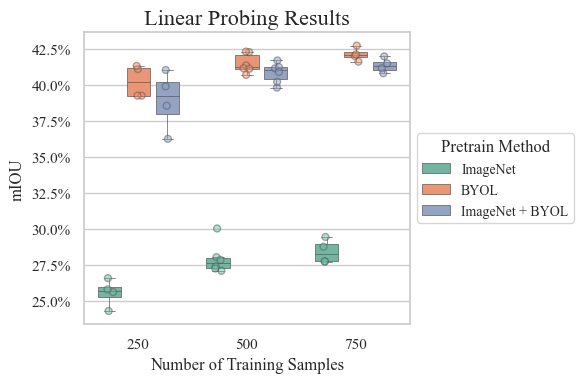

C:\Users\dh2306\AppData\Local\Temp\ipykernel_71908\1565471762.py:104: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='Pretrain Method',
C:\Users\dh2306\AppData\Local\Temp\ipykernel_71908\1565471762.py:104: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='Pretrain Method',
C:\Users\dh2306\AppData\Local\Temp\ipykernel_71908\1565471762.py:104: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='Pretrain Method',
C:\Users\dh2306\AppData\Local\Temp\ipykernel_71908\1565471762.py:104: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to m

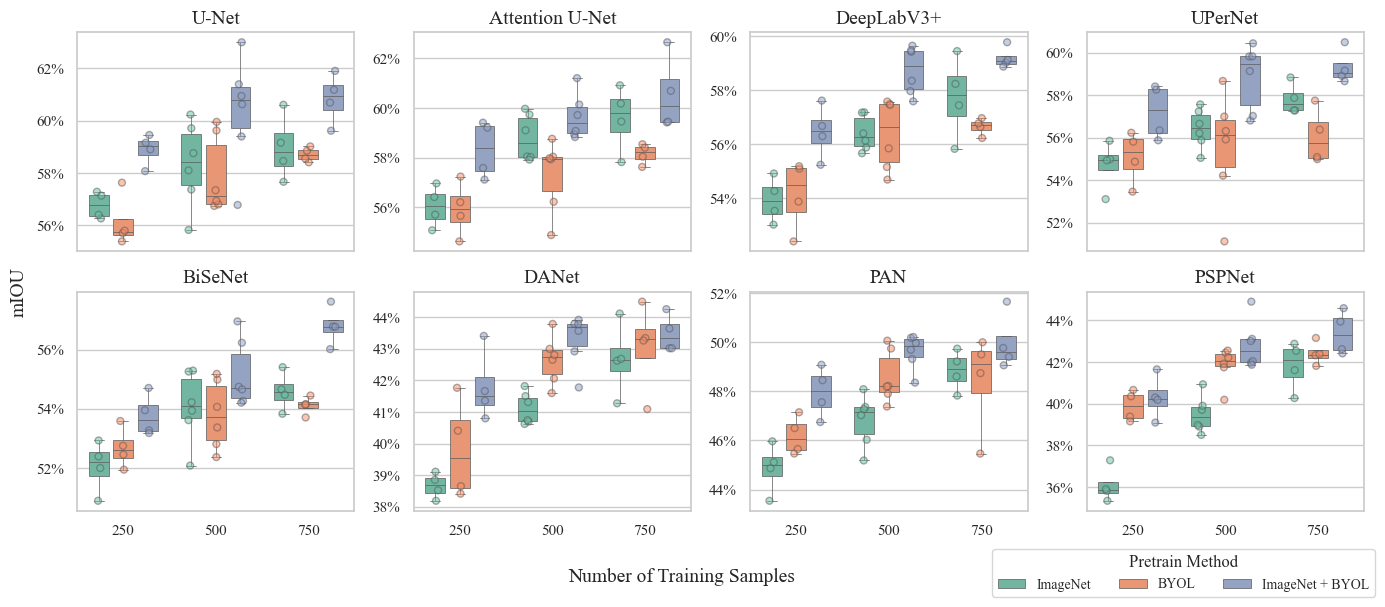

In [ ]:
# --- Plot 1: Linear Probing Results ---
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import PercentFormatter

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'times new roman'

# --- Data Preparation ---
metrics_df_temp = metrics_df.copy()
metrics_df_temp = metrics_df_temp.loc[metrics_df_temp['pretrain_method'] != 'none']

# Rename for clarity in the plot
metrics_df_temp['Pretrain Method'] = metrics_df_temp['pretrain_method'].replace({
    'byol': 'ImageNet + BYOL',
    'imagenet': 'ImageNet',
    'byol_randinit': 'BYOL'
})
metrics_df_temp['Pretrain Method'] = metrics_df_temp['Pretrain Method'].astype('category').cat.reorder_categories([
    'ImageNet', 'BYOL', 'ImageNet + BYOL'
], ordered=True)

# Filter for linear probing data
linear_probe_df = metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'].copy()

# --- Plotting ---
size=4
fig, ax = plt.subplots(figsize=(1.5*size, size))

sns.boxplot(data=linear_probe_df,
            x='n_train', y='macro_jaccard', hue='Pretrain Method', 
            ax=ax, dodge=True, palette='Set2', gap=0.2, linewidth=0.5, showfliers=False)
sns.stripplot(data=linear_probe_df,
              x='n_train', y='macro_jaccard', hue='Pretrain Method',
                ax=ax, dodge=True, palette='Set2', alpha=0.5, linewidth=1, edgecolor='gray', legend=False)

ax.set_title('Linear Probing Results', fontsize=16)
ax.set_xlabel('Number of Training Samples', fontsize=12)
ax.set_ylabel('mIOU', fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
ax.legend(loc='center left', title='Pretrain Method', bbox_to_anchor=(1, 0.5), fontsize=10)

fig.tight_layout()
plt.savefig('./paper/images/linear_probing_results.pdf')
plt.savefig('./paper/images/linear_probing_results.png', dpi=300)
plt.show()


sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'times new roman'

# --- Data Preparation ---
metrics_df_temp = metrics_df.copy()
metrics_df_temp = metrics_df_temp.loc[metrics_df_temp['pretrain_method'] != 'none']

# Filter out linear probe and non-finetuning runs
finetune_df = metrics_df_temp[(metrics_df_temp['model'] != 'linear_probe') & (metrics_df_temp['frozen_encoder'] == False)].copy()

# Rename models for display
finetune_df['model'] = finetune_df['model'].replace({
    'unet': 'U-Net',
    'deeplabv3plus': 'DeepLabV3+',
    'pan': 'PAN',
    'danet': 'DANet',
    'upernet': 'UPerNet',
    'bisenet': 'BiSeNet',
    'pspnet': 'PSPNet',
    'attention_unet': 'Attention U-Net',
})

# Rename pretrain methods for display
finetune_df['Pretrain Method'] = finetune_df['pretrain_method'].replace({
    'byol': 'ImageNet + BYOL',
    'imagenet': 'ImageNet',
    'byol_randinit': 'BYOL'
})

# Set order for models and pretrain methods
finetune_df['Pretrain Method'] = finetune_df['Pretrain Method'].astype('category').cat.reorder_categories([
    'ImageNet', 'BYOL', 'ImageNet + BYOL'
], ordered=True)

model_order = [
    'U-Net', 'Attention U-Net', 'DeepLabV3+', 'UPerNet',
    'BiSeNet', 'DANet', 'PAN', 'PSPNet',
]
finetune_df['model'] = finetune_df['model'].astype('category').cat.reorder_categories(model_order, ordered=True)
finetune_df = finetune_df.sort_values('model')
finetune_df['n_train'] = finetune_df['n_train'].astype(int)

# --- Plotting ---
fig, axes = plt.subplots(2, 4, figsize=(3.5*size, 1.5*size), sharey=False, sharex=True)
axes = axes.flatten() # Flatten for easy iteration

for i, model in enumerate(model_order):
    ax = axes[i]
    subset = finetune_df[finetune_df['model'] == model]
    
    sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='Pretrain Method',
                ax=ax, dodge=True, palette='Set2', 
                legend=True if i == 0 else False, gap=0.2, fliersize=4, linewidth=0.5, showfliers=False)
    sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='Pretrain Method',
                  ax=ax, dodge=True, palette='Set2', alpha=0.5, linewidth=1, edgecolor='gray', legend=False)
    
    ax.set_title(model, fontsize=14)
    ax.set_ylabel('') # Clear individual y-labels
    ax.set_xlabel('') # Clear individual x-labels
    ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

# Set shared labels
fig.supylabel('mIOU', fontsize=14)
fig.supxlabel('Number of Training Samples', fontsize=14)

# Create and place a single legend for the whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', bbox_to_anchor=(1, 0), ncol=3, title='Pretrain Method', fontsize=10)
axes[0].legend_.remove()  # Remove the legend from the first subplot

# plt.tight_layout(rect=[0.03, 0.03, 1, 1]) # Adjust layout to make room for legend
fig.tight_layout()

plt.savefig('./paper/images/finetuning_results.pdf')
plt.savefig('./paper/images/finetuning_results.png', dpi=300)
plt.show()

In [103]:
# generate a table with mean accuracy, macro jaccard for each model, pretrainn method, and n_train combination

mean_metics_df = finetune_df.groupby(['model', 'Pretrain Method', 'n_train']).agg(
    mean_accuracy=('accuracy', 'mean'),
    mean_macro_jaccard=('macro_jaccard', 'mean'),
).reset_index()
mean_metics_df = mean_metics_df.loc[(mean_metics_df['Pretrain Method'] != 'None') & (mean_metics_df['model'] == 'U-Net')]

# convert to percentage
mean_metics_df['mean_accuracy'] = mean_metics_df['mean_accuracy'] * 100
mean_metics_df['mean_macro_jaccard'] = mean_metics_df['mean_macro_jaccard'] * 100

display(mean_metics_df)

max_metrics_df = finetune_df.groupby(['model', 'Pretrain Method', 'n_train']).agg(
    max_accuracy=('accuracy', 'max'),
    max_macro_jaccard=('macro_jaccard', 'max'),
).reset_index()
max_metrics_df = max_metrics_df.loc[(max_metrics_df['Pretrain Method'] != 'None') & (max_metrics_df['model'] == 'U-Net')]

# convert to percentage
max_metrics_df['max_accuracy'] = max_metrics_df['max_accuracy'] * 100
max_metrics_df['max_macro_jaccard'] = max_metrics_df['max_macro_jaccard'] * 100

display(max_metrics_df)

C:\Users\dh2306\AppData\Local\Temp\ipykernel_71908\2564544940.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_metics_df = finetune_df.groupby(['model', 'Pretrain Method', 'n_train']).agg(


,model,Pretrain Method,n_train,mean_accuracy,mean_macro_jaccard
0,U-Net,ImageNet,250,85.204000,56.768009
1,U-Net,ImageNet,500,85.696667,58.332960
2,U-Net,ImageNet,750,86.104000,58.973782
3,U-Net,BYOL,250,85.341000,56.125655
4,U-Net,BYOL,500,86.195333,57.898945
5,U-Net,BYOL,750,86.246000,58.707838
6,U-Net,ImageNet + BYOL,250,85.946000,58.897566
7,U-Net,ImageNet + BYOL,500,86.550000,60.359523
8,U-Net,ImageNet + BYOL,750,86.428000,60.851484


C:\Users\dh2306\AppData\Local\Temp\ipykernel_71908\2564544940.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  max_metrics_df = finetune_df.groupby(['model', 'Pretrain Method', 'n_train']).agg(


,model,Pretrain Method,n_train,max_accuracy,max_macro_jaccard
0,U-Net,ImageNet,250,85.400,57.281695
1,U-Net,ImageNet,500,86.200,60.237492
2,U-Net,ImageNet,750,86.660,60.612650
3,U-Net,BYOL,250,85.616,57.629868
4,U-Net,BYOL,500,86.836,59.957926
5,U-Net,BYOL,750,86.576,59.016645
6,U-Net,ImageNet + BYOL,250,86.440,59.456537
7,U-Net,ImageNet + BYOL,500,87.420,63.005163
8,U-Net,ImageNet + BYOL,750,86.608,61.909370


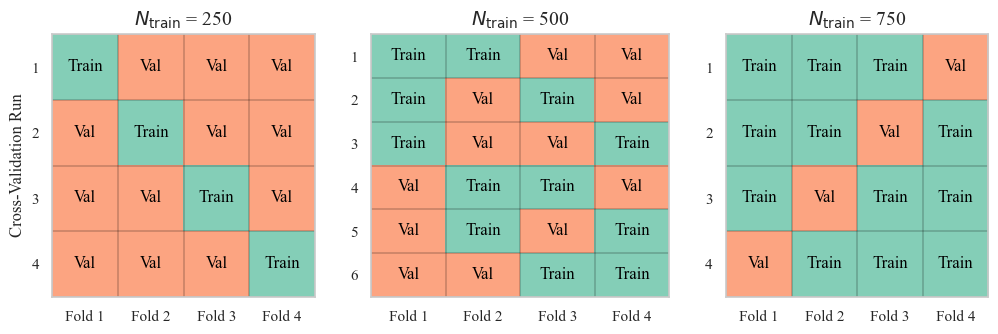

In [133]:
# fold plots
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# custom colormap:
set2_colors = sns.color_palette('Set2', n_colors=2)
import matplotlib.colors as mcolors
cmap = mcolors.ListedColormap(set2_colors)

splits_df = pd.read_csv('./data/splits/splits.csv')
# display(splits_df)

size = 3.5
fig, axes = plt.subplots(1, len(splits_df['n_train'].unique()), 
                        figsize=(3*size, size), sharex=True)

colors = {'train': 'lightblue', 'val': 'lightcoral'}

for i, n_train in enumerate(splits_df['n_train'].unique()):
    subset = splits_df[splits_df['n_train'] == n_train]
    
    # Create grid for this n_train
    grid_data = np.zeros((len(subset), 4))
    for j, (_, row) in enumerate(subset.iterrows()):
        for k, split in enumerate(['split_1', 'split_2', 'split_3', 'split_4']):
            grid_data[j, k] = row[split] == 'val'
    
    im = axes[i].imshow(grid_data, cmap=cmap, aspect='auto' if i == 1 else 'equal', alpha=0.8)
    
    # Add text annotations
    for j in range(len(subset)):
        for k in range(4):
            role = subset.iloc[j][f'split_{k+1}'].replace('train', 'Train').replace('val', 'Val')
            axes[i].text(k, j, role, ha='center', va='center', 
                        color='black' if grid_data[j, k] == 1 else 'black')
    
    for x in range(4 + 1):  # vertical lines
        axes[i].axvline(x - 0.5, color='black', linewidth=0.25)
    for y in range(len(subset) + 1):  # horizontal lines
        axes[i].axhline(y - 0.5, color='black', linewidth=0.25)
    
    
    axes[i].set_title(r'$N_{\text{train}}$ = ' + str(n_train))
    axes[i].set_yticks(range(len(subset)))
    axes[i].set_yticklabels(subset['fold'].values)
    
    # if i == len(splits_df['n_train'].unique()) - 1:
    # axes[i].set_xlabel('Split')
    axes[i].set_xticks(range(4))
    # axes[i].set_xticklabels(['Split 1', 'Split 2', 'Split 3', 'Split 4'])
    axes[i].set_xticklabels(['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4'])

axes[0].set_ylabel('Cross-Validation Run')

for ax in axes:
    ax.grid(False)
    ax.title.set_fontsize(14)
    
fig.tight_layout()
plt.savefig('./paper/images/fold_splits.pdf', bbox_inches='tight')
plt.savefig('./paper/images/fold_splits.png', bbox_inches='tight', dpi=300)
plt.show()

C:\Users\dh2306\AppData\Local\Temp\ipykernel_39740\2434215442.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


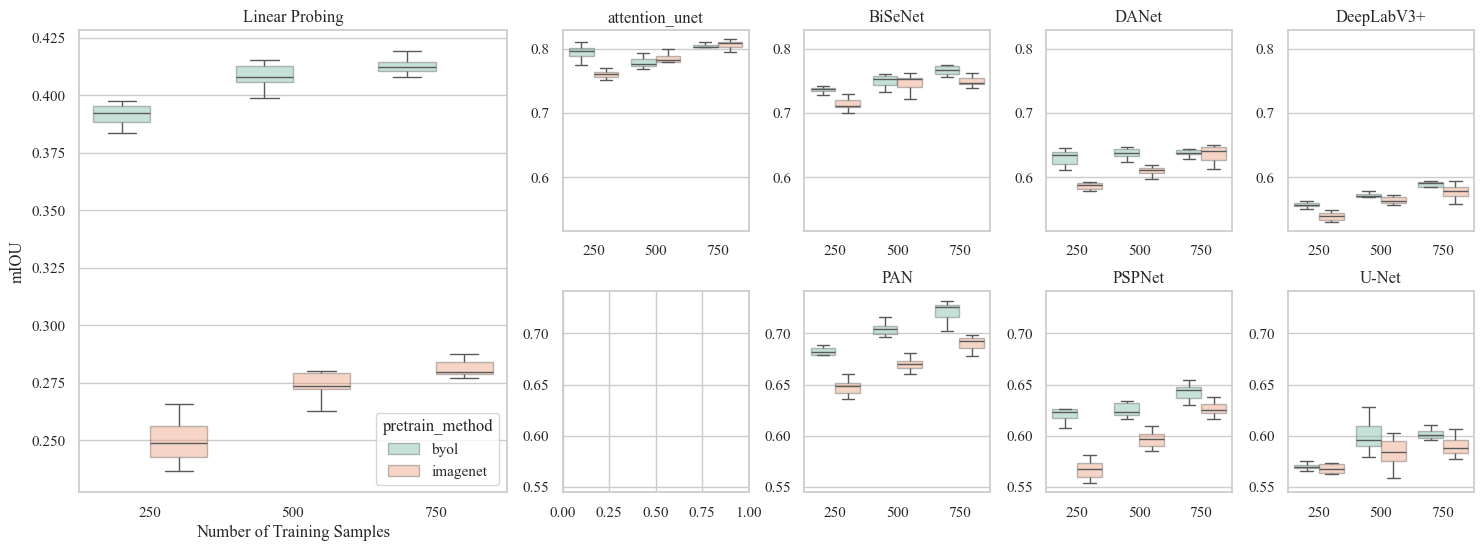

In [63]:
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(2, 6, hspace=0.3, wspace=0.3)

# Create the linear probe subplot (spans 2 rows)
lp_ax = fig.add_subplot(gs[0:2, 0:2])

# Create top row axes with shared y-axis
top_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in top row
        ax = fig.add_subplot(gs[0, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[0, j], sharey=top_axes[0])
        # ax = fig.add_subplot(gs[0, j])
    top_axes.append(ax)

# Create bottom row axes with shared y-axis
bottom_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in bottom row
        ax = fig.add_subplot(gs[1, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[1, j], sharey=bottom_axes[0])
        # ax = fig.add_subplot(gs[1, j])
    bottom_axes.append(ax)

# Combine all axes for easy iteration
axes = top_axes + bottom_axes

metrics_df_temp = metrics_df.copy()
# let's create some synthetic data real quick:
new_rows = []
metrics_df_temp.loc[~metrics_df_temp['model'].isin(['linear_probe', 'unet', 'deeplabv3plus']), 'macro_jaccard'] += 0.2

# for each observation where only 1 fold is present, create 5 more observations with the same data but different folds
# new_rows = []
# for i, row in metrics_df_temp.iterrows():
#     if row['model'] not in ['linear_probe', 'unet', 'deeplabv3plus']:
#         row['macro_jaccard'] += 0.2  # adjust the macro jaccard score for now

for i, row in metrics_df_temp.iterrows():
    if row['fold'] == '1' and row['model'] not in ['unet', 'deeplabv3plus']:
        for fold in range(1, 6):
            new_row = row.copy()
            new_row['fold'] = fold
            new_row['macro_jaccard'] += np.random.uniform(-0.01, 0.01)  # add some noise
            # new_row['macro_jaccard'] += 0.25
            new_rows.append(new_row)
            # metrics_df_temp = metrics_df_temp.append(new_row, ignore_index=True)
synthetic_df = pd.DataFrame(new_rows)
metrics_df_temp = pd.concat([metrics_df_temp, synthetic_df], ignore_index=True)

# rename to proper model names (i.e., unet -> U-Net)
metrics_df_temp['model'] = metrics_df_temp['model'].replace({
    'unet': 'U-Net',
    'deeplabv3plus': 'DeepLabV3+',
    'pan': 'PAN',
    'danet': 'DANet',
    'upernet': 'UPerNet',
    'bisenet': 'BiSeNet',
    'pspnet': 'PSPNet',
})
    

# Plot linear probe
sns.boxplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'], 
            x='n_train', y='macro_jaccard', hue='pretrain_method', 
            ax=lp_ax, palette='Set2', boxprops={'alpha': 0.4}, showfliers=False)
# sns.stripplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'],
#                 x='n_train', y='macro_jaccard', hue='pretrain_method', 
#                 ax=lp_ax, jitter=True, dodge=True, palette='Set2', size=10)
lp_ax.set_title('Linear Probing')
lp_ax.set_xlabel('Number of Training Samples')
lp_ax.set_ylabel('mIOU')


# Plot other models
for ax, model in zip(axes, metrics_df_temp['model'].unique()):
    if model == 'linear_probe':
        continue
    
    subset = metrics_df_temp[(metrics_df_temp['model'] == model) & (metrics_df_temp['frozen_encoder'] == False)]
    
    # if model not in ['deeplabv3plus', 'unet']:
        # subset['macro_jaccard'] = subset['macro_jaccard'] + 0.2
    
    sns.boxplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', 
                ax=ax, palette='Set2', boxprops={'alpha': 0.4}, showfliers=False, legend=False)
    # sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method',
    #               ax=ax, jitter=True, dodge=True, palette='Set2', size=10,
    #                 legend=False, alpha=0.7)
    
    ax.set_title(f'{model}')
    ax.set_xlabel('')
    
    # Only show y-label on leftmost plots of each row
    # if ax in [top_axes[0], bottom_axes[0]]:
        # ax.set_ylabel('mIOU')
    # else:
    ax.set_ylabel('')


fig.tight_layout()

C:\Users\dh2306\AppData\Local\Temp\ipykernel_24924\2825723249.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


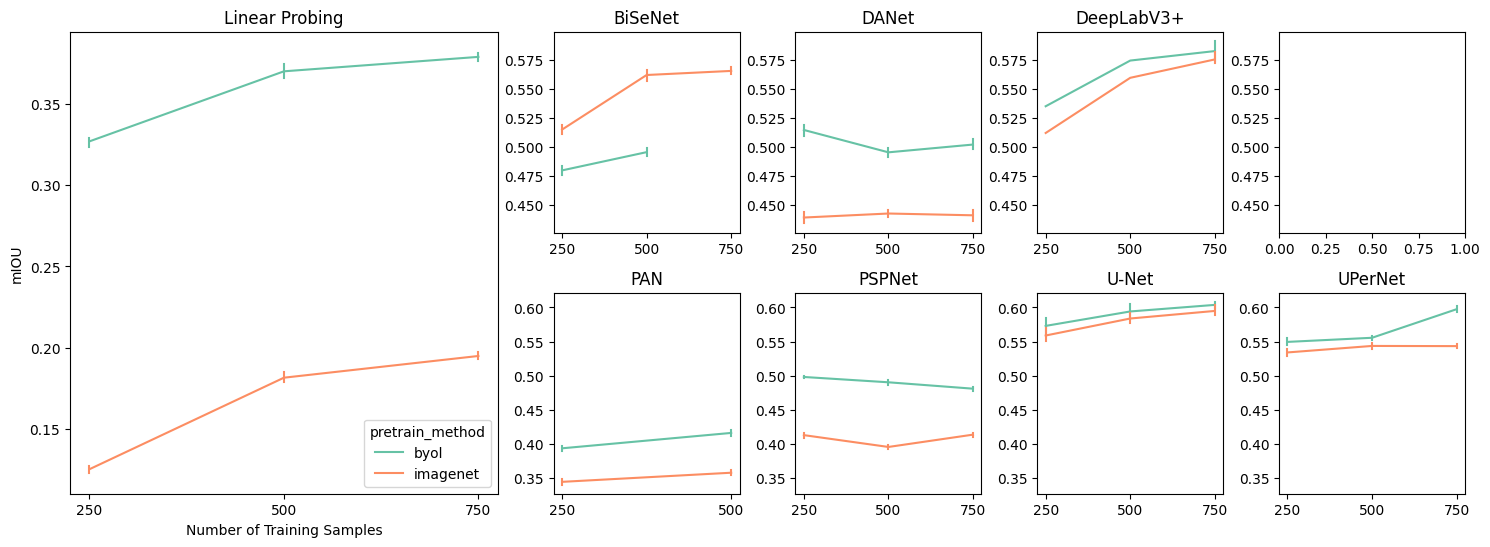

In [114]:
fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(2, 6, hspace=0.3, wspace=0.3)

# Create the linear probe subplot (spans 2 rows)
lp_ax = fig.add_subplot(gs[0:2, 0:2])

# Create top row axes with shared y-axis
top_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in top row
        ax = fig.add_subplot(gs[0, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[0, j], sharey=top_axes[0])
        # ax = fig.add_subplot(gs[0, j])
    top_axes.append(ax)

# Create bottom row axes with shared y-axis
bottom_axes = []
for j in range(2, 6):
    if j == 2:  # First subplot in bottom row
        ax = fig.add_subplot(gs[1, j])
    else:  # Share y-axis with first subplot
        ax = fig.add_subplot(gs[1, j], sharey=bottom_axes[0])
        # ax = fig.add_subplot(gs[1, j])
    bottom_axes.append(ax)

# Combine all axes for easy iteration
axes = top_axes + bottom_axes

metrics_df_temp = metrics_df.copy()
# let's create some synthetic data real quick:
new_rows = []
metrics_df_temp.loc[~metrics_df_temp['model'].isin(['linear_probe', 'unet', 'deeplabv3plus']), 'macro_jaccard'] += 0.2

# for each observation where only 1 fold is present, create 5 more observations with the same data but different folds
# new_rows = []
# for i, row in metrics_df_temp.iterrows():
#     if row['model'] not in ['linear_probe', 'unet', 'deeplabv3plus']:
#         row['macro_jaccard'] += 0.2  # adjust the macro jaccard score for now

for i, row in metrics_df_temp.iterrows():
    if row['fold'] == '1' and row['model'] not in ['unet', 'deeplabv3plus']:
        for fold in range(1, 6):
            new_row = row.copy()
            new_row['fold'] = fold
            new_row['macro_jaccard'] += np.random.uniform(-0.01, 0.01)  # add some noise
            # new_row['macro_jaccard'] += 0.25
            new_rows.append(new_row)
            # metrics_df_temp = metrics_df_temp.append(new_row, ignore_index=True)
synthetic_df = pd.DataFrame(new_rows)
metrics_df_temp = pd.concat([metrics_df_temp, synthetic_df], ignore_index=True)

# rename to proper model names (i.e., unet -> U-Net)
metrics_df_temp['model'] = metrics_df_temp['model'].replace({
    'unet': 'U-Net',
    'deeplabv3plus': 'DeepLabV3+',
    'pan': 'PAN',
    'danet': 'DANet',
    'upernet': 'UPerNet',
    'bisenet': 'BiSeNet',
    'pspnet': 'PSPNet',
})
    

# Plot linear probe
sns.lineplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'],
            x='n_train', y='macro_jaccard', hue='pretrain_method', 
            ax=lp_ax, palette='Set2', err_style='bars')
# sns.stripplot(data=metrics_df_temp[metrics_df_temp['model'] == 'linear_probe'],
#                 x='n_train', y='macro_jaccard', hue='pretrain_method', 
#                 ax=lp_ax, jitter=True, dodge=True, palette='Set2', size=10)
lp_ax.set_title('Linear Probing')
lp_ax.set_xlabel('Number of Training Samples')
lp_ax.set_ylabel('mIOU')


# Plot other models
for ax, model in zip(axes, metrics_df_temp['model'].unique()):
    if model == 'linear_probe':
        continue
    
    subset = metrics_df_temp[(metrics_df_temp['model'] == model) & (metrics_df_temp['frozen_encoder'] == False)]
    
    # if model not in ['deeplabv3plus', 'unet']:
        # subset['macro_jaccard'] = subset['macro_jaccard'] + 0.2
    

    sns.lineplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method',
                ax=ax, palette='Set2', legend=False, err_style='bars')
    # sns.catplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method', 
    #             ax=ax, palette='Set2', legend=False)
    # sns.stripplot(data=subset, x='n_train', y='macro_jaccard', hue='pretrain_method',
    #               ax=ax, jitter=True, dodge=True, palette='Set2', size=10,
    #                 legend=False, alpha=0.7)
    
    ax.set_title(f'{model}')
    ax.set_xlabel('')
    
    # Only show y-label on leftmost plots of each row
    # if ax in [top_axes[0], bottom_axes[0]]:
        # ax.set_ylabel('mIOU')
    # else:
    ax.set_ylabel('')


fig.tight_layout()

In [137]:
# best performing model overall
best_model = metrics_df.loc[metrics_df['macro_jaccard'].idxmax()]
print(best_model)

accuracy                    0.8742
f1_score                    0.8742
precision                   0.8742
recall                      0.8742
jaccard                   0.776514
kappa                     0.780977
cross_entropy             1.555658
brier_score               0.027611
macro_f1_score            0.758441
macro_precision           0.780296
macro_recall              0.767941
macro_jaccard             0.630052
macro_cross_entropy       1.658107
macro_brier_score         0.046478
weighted_f1_score         0.867835
weighted_precision        0.873818
weighted_recall             0.8742
weighted_jaccard          0.784597
weighted_cross_entropy    1.555658
weighted_brier_score      0.027611
model                         unet
pretrain_method               byol
frozen_encoder               False
n_train                        500
fold                             2
Name: 397, dtype: object


In [35]:
from mslandcover.models import UNet, ResNetBackboneUNet
import torch

model = UNet(
    backbone=ResNetBackboneUNet(
        in_channels=3,
        pretrained=False,
    )
)

model.to('cuda')

mean = torch.load('./weights/pretrain_mean.pth')
std = torch.load('./weights/pretrain_std.pth')

C:\Users\dh2306\AppData\Local\Temp\ipykernel_16784\1071517255.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mean = torch.load('./weights/pretrain_mean.pth')
C:\Users\

In [48]:
from glob import glob

val_target_paths = glob(os.path.join('data', 'splits', 'split_2', 'target', '*.tif')) + \
                   glob(os.path.join('data', 'splits', 'split_4', 'target', '*.tif'))

val_input_paths = [p.replace('target', 'input') for p in val_target_paths]

val_input_paths = sorted(val_input_paths)
val_target_paths = sorted(val_target_paths)

print(f'Found {len(val_input_paths)} validation input images and {len(val_target_paths)} target images.')

Found 500 validation input images and 500 target images.


In [49]:
import numpy as np
# from mslandcover.config import LEGEND_COLORS_RGB

cmap = rio.open(val_target_paths[1]).colormap(1)
targets = np.stack([rio.open(P).read(1) for P in val_target_paths], axis=0)
inputs_rgb = np.stack([rio.open(P).read([1, 2, 3]) for P in val_input_paths], axis=0)
inputs_cir = np.stack([rio.open(P).read([4, 1, 2]) for P in val_input_paths], axis=0)

print(f'Input RGB shape: {inputs_rgb.shape}, Input CIR shape: {inputs_cir.shape}, Targets shape: {targets.shape}')

Input RGB shape: (500, 3, 256, 256), Input CIR shape: (500, 3, 256, 256), Targets shape: (500, 256, 256)


In [52]:
import matplotlib.pyplot as plt

# colorize targets
def colorize_mask(mask, cmap=cmap):
    color_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
    for class_index, color in cmap.items():
        color_mask[mask == class_index] = color[:3]
    return color_mask

colorized_targets = np.stack([colorize_mask(mask) for mask in targets], axis=0)

In [31]:
inputs_torch = torch.from_numpy(inputs_rgb).float() / 255.0
inputs_torch = (inputs_torch - mean[None, :, None, None]) / std[None, :, None, None]

inputs_torch

tensor([[[[-2.5488, -1.9647, -2.1425,  ..., -2.4472, -2.1679, -1.5329],
          [-2.0409, -2.1171, -2.5234,  ..., -2.4218, -2.4218, -2.2441],
          [-2.3457, -2.1425, -2.3457,  ..., -2.5742, -2.2187, -2.3457],
          ...,
          [-3.9966, -3.7426, -3.7426,  ..., -0.8471, -1.1011, -2.0663],
          [-3.9712, -3.7680, -3.6918,  ..., -1.3805, -1.0503, -1.5583],
          [-3.7934, -3.5648, -3.5140,  ..., -1.4313, -0.8471, -1.1519]],

         [[ 0.2208,  0.7426,  0.6065,  ...,  0.5384,  0.6518,  1.0375],
          [ 0.6518,  0.6518,  0.3116,  ...,  0.5611,  0.3569,  0.3569],
          [ 0.3569,  0.5838,  0.4704,  ...,  0.2208,  0.3342,  0.3342],
          ...,
          [-1.3898, -1.1175, -1.1402,  ...,  1.0828,  0.9014,  0.3342],
          [-1.3671, -1.1856, -1.0949,  ...,  0.7652,  0.9694,  0.6518],
          [-1.1402, -0.8226, -0.7319,  ...,  0.7426,  1.1055,  0.9240]],

         [[-1.0425, -0.8540, -0.9078,  ..., -1.0425, -0.9886, -0.5039],
          [-0.7463, -0.8809, -

In [51]:
weights = ['none', 'imagenet', 'byol', 'byol_randinit']

preds = {}
preds_colorized = {}
batch_size = 128
accuracies = {}

for i, weight in enumerate(weights):
    model.load_state_dict(torch.load(f'./weights/finetune_20250829/unet/{weight}/randinit_false/frozenencoder_false/500/fold_2/best_model.pth'))
    model.eval()
    
    preds[weight] = []
    accuracies[weight] = []
    for batch_idx in range(0, len(inputs_torch), batch_size):
        inputs_batch = inputs_torch[batch_idx:batch_idx+batch_size].to('cuda')
        with torch.no_grad():
            outputs = model(inputs_batch)
            preds_batch = torch.argmax(outputs, dim=1).cpu().numpy() + 1 # add 1 to match target classes
        
        preds[weight].append(preds_batch)
        
    preds[weight] = np.concatenate(preds[weight], axis=0)
    preds_colorized[weight] = np.stack([colorize_mask(mask) for mask in preds[weight]], axis=0)
    

C:\Users\dh2306\AppData\Local\Temp\ipykernel_16784\4090628894.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'./weights/finetune_20250

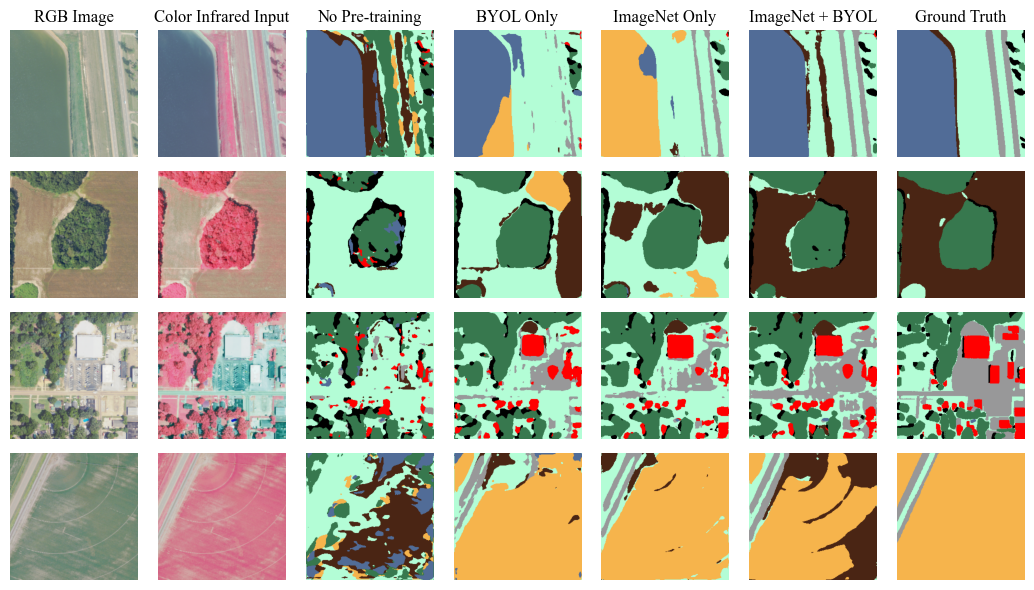

In [91]:
# n_samples = 50
# selected_indices = np.random.choice(len(inputs_rgb), size=n_samples, replace=False)
selected_indices = [475, 283, 132, 52]

plt.rcParams['font.family'] = 'times new roman'

scale_factor = 1.5
fig, ax = plt.subplots(len(selected_indices), 7, figsize=(scale_factor*7, scale_factor*len(selected_indices)))

inputs_rgb_samples = inputs_rgb[selected_indices].transpose(0, 2, 3, 1)
inputs_cir_samples = inputs_cir[selected_indices].transpose(0, 2, 3, 1)
targets_samples = colorized_targets[selected_indices]
preds_colorized_samples = {weight: preds_colorized[weight][selected_indices] for weight in weights}

for i in range(len(selected_indices)):
    
    ax[i, 0].imshow(inputs_rgb_samples[i])
    ax[i, 1].imshow(inputs_cir_samples[i])
    
    ax[i, 2].imshow(preds_colorized_samples['none'][i])
    ax[i, 3].imshow(preds_colorized_samples['byol_randinit'][i])
    ax[i, 4].imshow(preds_colorized_samples['imagenet'][i])
    ax[i, 5].imshow(preds_colorized_samples['byol'][i])
    
    ax[i, 6].imshow(targets_samples[i])
    
    for j in range(7):
        ax[i, j].axis('off')
        
    # ax[i, 6].set_title(selected_indices[i])

ax[0, 0].set_title('RGB Image')
ax[0, 1].set_title('Color Infrared Input')
ax[0, 2].set_title('No Pre-training')
ax[0, 3].set_title('BYOL Only')
ax[0, 4].set_title('ImageNet Only')
ax[0, 5].set_title('ImageNet + BYOL')
ax[0, 6].set_title('Ground Truth')

fig.tight_layout()

plt.savefig('./paper/images/qualitative_results.pdf', bbox_inches='tight')
plt.savefig('./paper/images/qualitative_results.png', bbox_inches='tight', dpi=300)

plt.show()

In [45]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from mslandcover.config import LEGEND_CLASSES

legend_classes_list = [v for k, v in sorted(LEGEND_CLASSES.items()) if k != 0]

results_df = pd.read_csv('./logs/assessment/assessment_results.csv')

cm = confusion_matrix(
    results_df['ground_truth_class_idx'],
    results_df['predicted_class_idx'],
)

# Confusion matrix whose i-th row and j-th column entry indicates the number of samples with true label being i-th class and predicted label being j-th class.


cm_df = pd.DataFrame(cm, index=legend_classes_list, columns=legend_classes_list)

# caluculate user and producer accuracy

cm_df_full = cm_df.copy()

cm_df.loc['User Accuracy'] = (cm_df_full.values.diagonal() / cm_df_full.sum(axis=0)) * 100
cm_df['Producer Accuracy'] = (cm_df_full.values.diagonal() / cm_df_full.sum(axis=1)) * 100

# overall accuracy
cm_df.loc['User Accuracy', 'Producer Accuracy'] = (np.trace(cm_df_full.values) / np.sum(cm_df_full.values)) * 100

cm_df['Producer Accuracy'] = cm_df['Producer Accuracy'].round(2)
cm_df.loc['User Accuracy'] = cm_df.loc['User Accuracy'].round(2)

# all other values rounded to 0 decimal places
cm_df.iloc[:-1, :-1] = cm_df.iloc[:-1, :-1].astype(int).astype(str)

cm_df = cm_df.astype(str)
cm_df

/var/folders/1j/_j01624x6y33h54v02qwk81r0000gn/T/ipykernel_2684/2027198577.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['511' '0' '1' '6' '1' '7' '0' '2']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cm_df.iloc[:-1, :-1] = cm_df.iloc[:-1, :-1].astype(int).astype(str)
/var/folders/1j/_j01624x6y33h54v02qwk81r0000gn/T/ipykernel_2684/2027198577.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['1' '80' '5' '4' '2' '2' '0' '11']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cm_df.iloc[:-1, :-1] = cm_df.iloc[:-1, :-1].astype(int).astype(str)
/var/folders/1j/_j01624x6y33h54v02qwk81r0000gn/T/ipykernel_2684/2027198577.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future v

,Open Water,Impervious Structures,Impervious Surfaces,Barren Land,Tree Canopy/Woody Vegetation,Low Vegetation/Herbaceous,Cultivated Crops,Unclassified,Producer Accuracy
Open Water,511,1,0,10,11,18,0,21,89.34
Impervious Structures,0,80,15,3,3,5,0,0,75.47
Impervious Surfaces,1,5,183,17,1,22,0,1,79.57
Barren Land,6,4,68,944,22,451,144,5,57.42
Tree Canopy/Woody Vegetation,1,2,2,6,14712,366,6,22,97.32
Low Vegetation/Herbaceous,7,2,20,138,376,3699,492,17,77.86
Cultivated Crops,0,0,0,17,2,38,1243,1,95.54
Unclassified,2,11,6,7,753,86,1,413,32.29
User Accuracy,96.78,76.19,62.24,82.66,92.64,78.95,65.91,86.04,87.14
